In [ ]:
pip install mtcnn

In [ ]:
pip install tensorflow

In [ ]:
pip install keras

In [ ]:
pip install h5py

In [ ]:
import mtcnn 
from mtcnn import MTCNN
import PIL
import numpy as np
from PIL import Image
from os import listdir
import os.path
from keras.optimizers import *
from keras.models import load_model
from matplotlib import pyplot
from numpy import savez_compressed
from numpy import asarray
from numpy import load
from numpy import expand_dims
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import Normalizer
from sklearn.svm import SVC
from random import choice

In [ ]:
!rm -r /content/sample_data/our_faces/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/train/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/train/alex/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/train/simona/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/train/vlad/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/val/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/val/alex/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/val/simona/.ipynb_checkpoints
!rm -r /content/sample_data/our_faces/val/vlad/.ipynb_checkpoints

In [7]:
def extract_face(filename, required_size=(160, 160)):
  image=Image.open(filename)
  image=image.convert('RGB')
  pixels=np.array(image)

  detector = MTCNN()
  results=detector.detect_faces(pixels)
  print(results)
  print(filename)
  x1, y1, width, height = results[0]['box']

  x1, y1 = abs(x1), abs(y1)
  x2, y2 = x1 + width, y1 + height 
  
  face = pixels[y1:y2, x1:x2]

  image = Image.fromarray(face)
  image = image.resize((160, 160)) 
  face_array = np.asanyarray(image)
  
  return face_array

In [8]:
def load_faces(folder):
  faces = list()
  
  for filename in listdir(folder):
    path = folder + filename

    face = extract_face(path)

    faces.append(face)
  
  return faces

In [9]:
def load_dataset(folder):
	X, Y = list(), list()
	
	for subdir in listdir(folder):
		if subdir not in ('.ipynb_checkpoints'):
			
			path = folder + subdir + '/'

			if not os.path.isdir(path):
				continue

			faces = load_faces(path)

			labels = [subdir for _ in range(len(faces))]

			print('>loaded %d examples for class: %s' % (len(faces), subdir))

			X.extend(faces)
			Y.extend(labels)
	return asarray(X), asarray(Y)

In [ ]:
model = load_model('/content/sample_data/facenet_keras.h5', compile=False)
print(model.input)
print(model.output)

In [ ]:
trainX, trainy = load_dataset('/content/sample_data/our_faces/train/')
print(trainX.shape, trainy.shape)

testX, testy = load_dataset('/content/sample_data/our_faces/val/')
print(testX.shape, testy.shape)

savez_compressed('our_faces.npz', trainX, trainy, testX, testy)

In [10]:
def get_embedding(model, face_pixels):

	face_pixels = face_pixels.astype('float32')

	mean, std = face_pixels.mean(), face_pixels.std()
	face_pixels = (face_pixels - mean) / std

	samples = expand_dims(face_pixels, axis=0)

	yhat = model.predict(samples)
	return yhat[0]

In [ ]:
data = load('our_faces.npz')
trainX, trainy, testX, testy = data['arr_0'], data['arr_1'], data['arr_2'], data['arr_3']
print('Loaded: ', trainX.shape, trainy.shape, testX.shape, testy.shape)

model = load_model('/content/sample_data/facenet_keras.h5',compile=False)
print('Loaded Model')

newTrainX = list()
for face_pixels in trainX:
	embedding = get_embedding(model, face_pixels)
	newTrainX.append(embedding)
newTrainX = asarray(newTrainX)
print(newTrainX.shape)

newTestX = list()
for face_pixels in testX:
	embedding = get_embedding(model, face_pixels)
	newTestX.append(embedding)
newTestX = asarray(newTestX)
print(newTestX.shape)

savez_compressed('our_faces_embeddings.npz', newTrainX, trainy, newTestX, testy)

In [ ]:
data = load('/content/sample_data/our_faces.npz')
testX_faces = data['arr_2']

data = load('/content/sample_data/our_faces_embeddings.npz')
trainX, trainy, testX, testy = data['arr_0'], data['arr_1'], data['arr_2'], data['arr_3']

in_encoder = Normalizer(norm='l2')
trainX = in_encoder.transform(trainX)
testX = in_encoder.transform(testX)

out_encoder = LabelEncoder()
out_encoder.fit(trainy)
trainy = out_encoder.transform(trainy)
testy = out_encoder.transform(testy)

model = SVC(kernel='linear', probability=True)
model.fit(trainX, trainy)

selection = choice([i for i in range(testX.shape[0])])
random_face_pixels = testX_faces[selection]
random_face_emb = testX[selection]
random_face_class = testy[selection]
random_face_name = out_encoder.inverse_transform([random_face_class])

samples = expand_dims(random_face_emb, axis=0)
yhat_class = model.predict(samples)
yhat_prob = model.predict_proba(samples)

class_index = yhat_class[0]
class_probability = yhat_prob[0,class_index] * 100
predict_names = out_encoder.inverse_transform(yhat_class)
print('Predicted: %s (%.3f)' % (predict_names[0], class_probability))
print('Expected: %s' % random_face_name[0])

pyplot.imshow(random_face_pixels)
title = '%s (%.3f)' % (predict_names[0], class_probability)
pyplot.title(title)
pyplot.show()

In [12]:
def recongnize(imageURL):
	# load faces
	data = load('/content/sample_data/our_faces.npz')
	testX_faces = data['arr_2']
	
	
	data = load('/content/sample_data/our_faces_embeddings.npz')
	trainX, trainy, testX, testy = data['arr_0'], data['arr_1'], data['arr_2'], data['arr_3']
	

	in_encoder = Normalizer(norm='l2')
	trainX = in_encoder.transform(trainX)
	testX = in_encoder.transform(testX)
	
	out_encoder = LabelEncoder()
	out_encoder.fit(trainy)
	trainy = out_encoder.transform(trainy)
	
	model = SVC(kernel='linear', probability=True)
	model.fit(trainX, trainy)
	
	modelK = load_model('/content/sample_data/facenet_keras.h5',compile=False)
	random_face_pixels = extract_face(imageURL)
	random_face_emb = get_embedding(modelK,random_face_pixels)
	
	samples = expand_dims(random_face_emb, axis=0)
	yhat_class = model.predict(samples)
	yhat_prob = model.predict_proba(samples)

	class_index = yhat_class[0]
	class_probability = yhat_prob[0,class_index] * 100
	predict_names = out_encoder.inverse_transform(yhat_class)
	print('Predicted: %s (%.3f)' % (predict_names[0], class_probability))

	pyplot.imshow(random_face_pixels) #transform into image and output
	title = '%s (%.3f)' % (predict_names[0], class_probability)
	pyplot.title(title)
	pyplot.show()

[{'box': [41, 215, 420, 498], 'confidence': 0.9999985694885254, 'keypoints': {'left_eye': (171, 415), 'right_eye': (362, 419), 'nose': (276, 475), 'mouth_left': (187, 591), 'mouth_right': (345, 597)}}]
/content/sample_data/vlad.JPEG
Predicted: vlad (100.000)


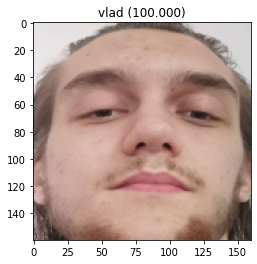

[{'box': [653, 481, 367, 454], 'confidence': 0.9997547268867493, 'keypoints': {'left_eye': (785, 652), 'right_eye': (933, 737), 'nose': (820, 807), 'mouth_left': (706, 805), 'mouth_right': (834, 876)}}]
/content/sample_data/simona.jpeg
Predicted: simona (100.000)


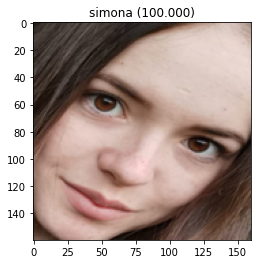

[{'box': [1037, 113, 521, 699], 'confidence': 0.9999951124191284, 'keypoints': {'left_eye': (1196, 413), 'right_eye': (1427, 398), 'nose': (1312, 520), 'mouth_left': (1220, 664), 'mouth_right': (1405, 652)}}]
/content/sample_data/alexandru.JPEG
Predicted: alex (100.000)


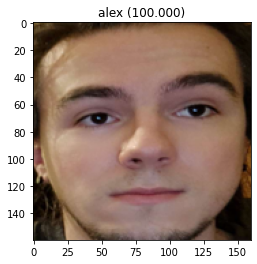

In [17]:
recongnize('/content/sample_data/vlad.JPEG')
recongnize('/content/sample_data/simona.jpeg')
recongnize('/content/sample_data/alexandru.JPEG')